In [2]:
import pandas as pd
df=pd.read_csv("D:\Geoloc_DA\data cleaning\Cleaned_GeoData.xls")
print(df)

     coffee  cook  drink  eating_out  employment  exercise  fruit_day  income  \
0         1   2.0    1.0           3         3.0       1.0          5     5.0   
1         2   3.0    2.0           2         2.0       1.0          4     4.0   
2         2   1.0    1.0           2         3.0       2.0          5     6.0   
3         2   2.0    2.0           2         3.0       3.0          4     6.0   
4         2   1.0    2.0           2         2.0       1.0          4     6.0   
..      ...   ...    ...         ...         ...       ...        ...     ...   
120       2   3.0    2.0           2         1.0       2.0          5     4.0   
121       2   3.0    1.0           4         3.0       2.0          4     2.0   
122       1   3.0    1.0           3         3.0       2.0          4     2.0   
123       1   3.0    2.0           5         2.0       1.0          5     4.0   
124       2   NaN    1.0           1         2.0       2.0          3     5.0   

     on_off_campus  pay_mea

In [3]:
cluster_df = df[[
    'cook',
    'eating_out',
    'exercise',
    'fruit_day',
    'income',
    'on_off_campus',
    'pay_meal_out',
    'sports',
    'veggies_day'
]].copy()

## Handle the remaining missing values - Assigning them the mediun

In [4]:
cluster_df.isnull().sum()

cook              3
eating_out        0
exercise         13
fruit_day         0
income            1
on_off_campus     1
pay_meal_out      0
sports            2
veggies_day       0
dtype: int64

In [5]:
cluster_df = cluster_df.fillna(cluster_df.median())

In [6]:
cluster_df.isnull().sum()

cook             0
eating_out       0
exercise         0
fruit_day        0
income           0
on_off_campus    0
pay_meal_out     0
sports           0
veggies_day      0
dtype: int64

## scaling of data

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster_df)

## k means 

In [11]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    inertia.append(model.inertia_)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

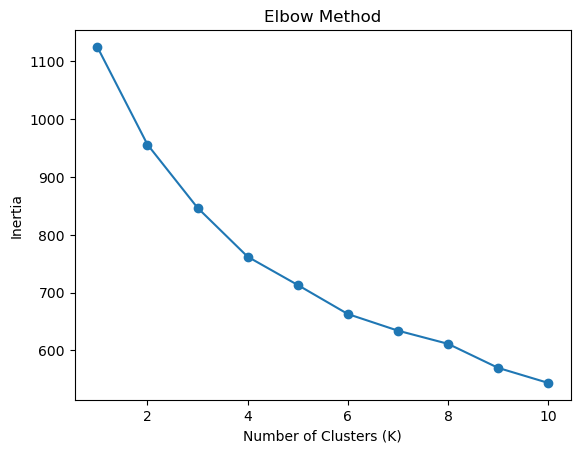

In [12]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

steep decline → relatively gradual decline

That bend is the elbow.

In [13]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

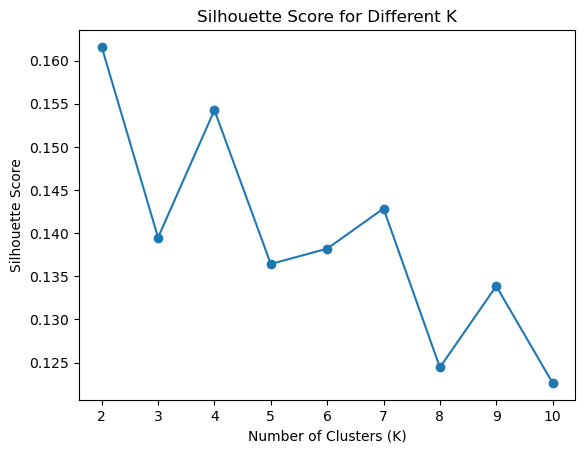

In [14]:
plt.plot(range(2, 11), scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K')

plt.show()

## Key Takeaways from Your Graph
1. Overall Low Scores:Notice that all your scores are between 0.12 and 0.16.In practical terms, these are quite low. It means your data naturally forms a single continuous cloud or gradual spectrum rather than distinct, separate clusters.
2. K = 2 is Technically the Best (Score $\approx 0.162$):The highest peak is at $K = 2$. If you must divide your data into separate groups based purely on distance, splitting it into 2 main groups gives the cleanest boundary.
3. K = 4 is the Best Secondary Option (Score $\approx 0.154$):If 2 clusters is too simple for your business case or analysis, $K = 4$ shows a distinct local peak. It retains a relatively higher score before dropping off sharply at higher values of $K.
4. Avoid K 8$:Beyond $K = 7$, the score drops to its lowest points ($0.122$–$0.133$), showing that forcing the data into 8 or more clusters creates arbitrary splits with heavy overlap.

In [15]:
optimal_k = 2

In [16]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [17]:
cluster_summary = cluster_df.groupby('Cluster').mean()

cluster_summary

,cook,eating_out,exercise,fruit_day,income,on_off_campus,pay_meal_out,sports,veggies_day
Cluster,,,,,,,,,
0,2.926829,2.341463,1.902439,3.219512,4.414634,1.243902,3.682927,1.487805,2.902439
1,2.726190,2.666667,1.345238,4.714286,4.595238,1.357143,3.273810,1.333333,4.547619


## Visualization 

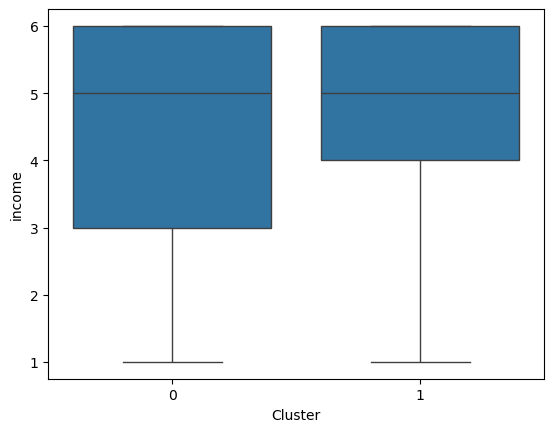

In [18]:
import seaborn as sns

sns.boxplot(
    x='Cluster',
    y='income',
    data=cluster_df
)

plt.show()

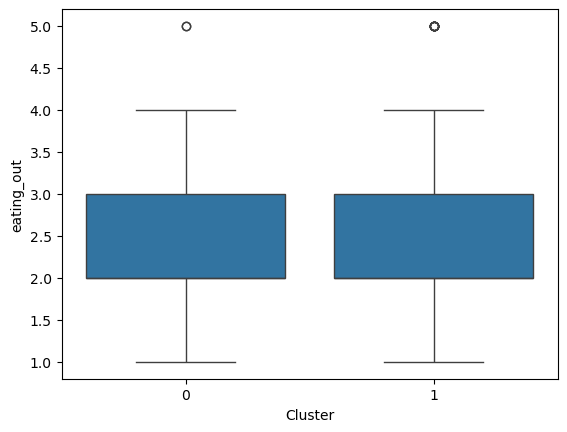

In [19]:
sns.boxplot(
    x='Cluster',
    y='eating_out',
    data=cluster_df
)

plt.show()

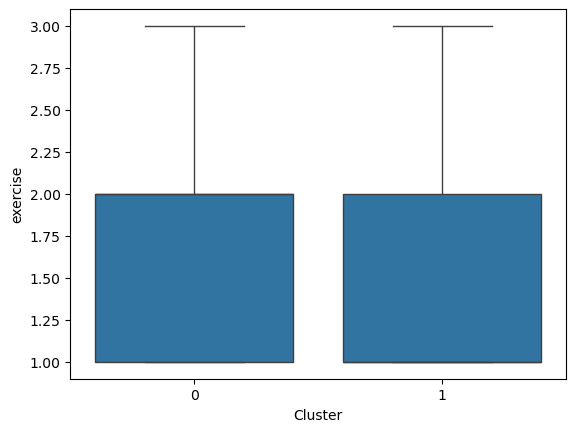

In [20]:
sns.boxplot(
    x='Cluster',
    y='exercise',
    data=cluster_df
)

plt.show()

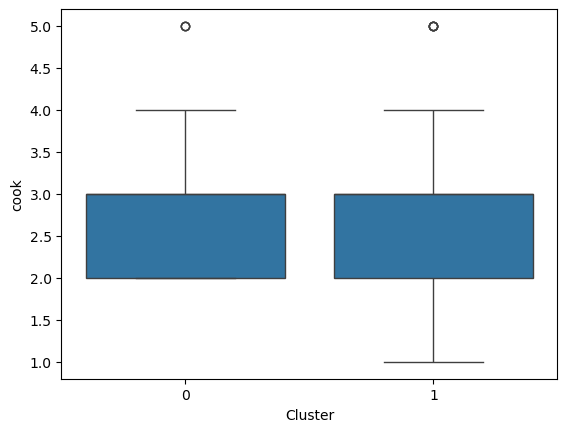

In [22]:
sns.boxplot(
    x='Cluster',
    y='cook',
    data=cluster_df
)

plt.show()